In [1]:
from soil_diskin.continuum_models import PowerLawDisKin, LognormalDisKin
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# ln = pd.read_csv('results/03_calibrate_models/03b_lognormal_predictions_calcurve.csv')
ln = pd.read_csv('results/04_model_predictions/04b_lognormal_cdfs.csv')
pl = pd.read_csv('results/03_calibrate_models/powerlaw_model_optimization_results.csv')
ln.columns = ln.columns.str.strip().astype(float)

In [4]:

row = ln.loc[0]
sig = np.sqrt(np.log(row['pred']/row['turnover']));
mu = -np.log(np.sqrt(row['turnover']**3/row['pred']));
ln_model = LognormalDisKin(mu=mu, sigma=sig)
ln_s = np.vectorize(ln_model.s)

KeyError: 'pred'

In [35]:
PowerLawDisKin(*pl[['t_min', 't_max']].values[0]).cdfA(ages)

array([0.05598323, 0.06122403, 0.06681949, 0.07277366, 0.0790882 ,
       0.08576235, 0.09279294, 0.10017447, 0.10789926, 0.11595767,
       0.12433826, 0.13302815, 0.14201324, 0.15127849, 0.16080827,
       0.17058654, 0.18059716, 0.19082407, 0.2012515 , 0.21186413,
       0.22264717, 0.23358652, 0.24466879, 0.25588136, 0.26721243,
       0.27865097, 0.29018677, 0.30181036, 0.31351305, 0.32528682,
       0.33712435, 0.34901891, 0.36096439, 0.37295517, 0.38498614,
       0.39705263, 0.40915036, 0.42127542, 0.43342422, 0.44559343,
       0.45777997, 0.46998099, 0.48219379, 0.49441582, 0.50664466,
       0.51887793, 0.53111336, 0.54334865, 0.55558154, 0.5678097 ,
       0.58003077, 0.59224228, 0.60444163, 0.61662607, 0.62879265,
       0.64093822, 0.65305932, 0.66515222, 0.6772128 , 0.68923656,
       0.70121854, 0.71315328, 0.72503473, 0.73685622, 0.74861038,
       0.76028906, 0.77188326, 0.78338305, 0.79477751, 0.80605462,
       0.81720118, 0.82820275, 0.83904358, 0.84970654, 0.86017

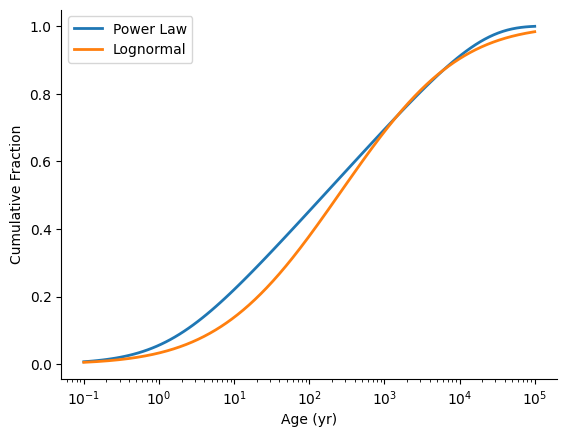

In [12]:
fig, ax = plt.subplots()
for i in [1]:
    ages = 10 ** np.linspace(-1, 5, 100)
    plt.semilogx(ages, PowerLawDisKin(*pl[['t_min', 't_max']].values[i]).cdfA(ages), label='Power Law', color='C0', lw=2)
    # plt.loglog(ages, ln_s(ages), label='Lognormal')
    (ln.loc[i]/ pl.loc[i]['turnover']).plot(logx=True, color='C1', lw=2, label='Lognormal')
    ax.set(xlabel='Age (yr)', ylabel='Cumulative Fraction')

# remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()